# **BLOCK 1: INSTALL YOLOv8 AND DEPENDENCIES**

In [1]:
# ============================================================================
# BLOCK 1: INSTALL YOLOv8 AND DEPENDENCIES
# ============================================================================

print("="*70)
print("INSTALLING YOLOv8 AND DEPENDENCIES")
print("="*70)

# Install ultralytics
!pip install ultralytics -q

# Verify installation
import ultralytics
from ultralytics import YOLO
import torch
import os
import yaml
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

print(f"✅ YOLOv8 version: {ultralytics.__version__}")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("="*70)

INSTALLING YOLOv8 AND DEPENDENCIES
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 version: 8.4.48
✅ PyTorch version: 2.10.0+cu128
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 15.6 GB


# **BLOCK 2: DATASET PATHS AND VERIFICATION**

In [2]:
# ============================================================================
# BLOCK 2: DATASET PATHS AND VERIFICATION - BALANCED DATASET
# ============================================================================

print("="*70)
print("DATASET VERIFICATION - BALANCED DATASET")
print("="*70)

# Your balanced dataset path on Kaggle
BASE_PATH = "/kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED"

# Paths to splits
TRAIN_IMAGES = os.path.join(BASE_PATH, "train", "images")
TRAIN_LABELS = os.path.join(BASE_PATH, "train", "labels")
VAL_IMAGES = os.path.join(BASE_PATH, "val", "images")
VAL_LABELS = os.path.join(BASE_PATH, "val", "labels")
TEST_IMAGES = os.path.join(BASE_PATH, "test", "images")
TEST_LABELS = os.path.join(BASE_PATH, "test", "labels")

WORKING_DIR = "/kaggle/working"

print(f"📁 Base path: {BASE_PATH}")
print(f"📁 Train images: {TRAIN_IMAGES}")
print(f"📁 Train labels: {TRAIN_LABELS}")
print(f"📁 Val images: {VAL_IMAGES}")
print(f"📁 Test images: {TEST_IMAGES}")

# Verify paths exist
for path, name in [(TRAIN_IMAGES, "Train images"), (TRAIN_LABELS, "Train labels"),
                   (VAL_IMAGES, "Val images"), (VAL_LABELS, "Val labels"),
                   (TEST_IMAGES, "Test images"), (TEST_LABELS, "Test labels")]:
    exists = os.path.exists(path)
    print(f"  {name}: {'✅' if exists else '❌'}")

# Count images
train_count = len([f for f in os.listdir(TRAIN_IMAGES) if f.endswith(('.jpg', '.jpeg', '.png'))])
val_count = len([f for f in os.listdir(VAL_IMAGES) if f.endswith(('.jpg', '.jpeg', '.png'))])
test_count = len([f for f in os.listdir(TEST_IMAGES) if f.endswith(('.jpg', '.jpeg', '.png'))])

print(f"\n📊 DATASET STATISTICS:")
print(f"   Training: {train_count} images")
print(f"   Validation: {val_count} images")
print(f"   Test: {test_count} images")
print(f"   TOTAL: {train_count + val_count + test_count} images")
print(f"\n📐 SPLIT RATIO:")
total = train_count + val_count + test_count
print(f"   Train: {train_count/total*100:.1f}%")
print(f"   Val: {val_count/total*100:.1f}%")
print(f"   Test: {test_count/total*100:.1f}%")
print("="*70)

DATASET VERIFICATION - BALANCED DATASET
📁 Base path: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED
📁 Train images: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED/train/images
📁 Train labels: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED/train/labels
📁 Val images: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED/val/images
📁 Test images: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED/test/images
  Train images: ✅
  Train labels: ✅
  Val images: ✅
  Val labels: ✅
  Test images: ✅
  Test labels: ✅

📊 DATASET STATISTICS:
   Training: 4200 images
   Validation: 900 images
   Test: 549 images
   TOTAL: 5649 images

📐 SPLIT RATIO:
   Train: 74.3%
   Val: 15.9%
   Test: 9.7%


# **BLOCK 3: CREATE DATA.YAML CONFIGURATION FILE**

In [3]:
# ============================================================================
# BLOCK 3: CREATE DATA.YAML CONFIGURATION FILE
# ============================================================================

print("="*70)
print("CREATING DATA.YAML FOR YOLOv8")
print("="*70)

# Create data.yaml for YOLOv8
data_yaml = {
    'path': BASE_PATH,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,  # number of classes
    'names': ['fracture']
}

# Save to working directory
yaml_path = os.path.join(WORKING_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ data.yaml saved to: {yaml_path}")
print("\n📋 data.yaml contents:")
print("="*40)
with open(yaml_path, 'r') as f:
    print(f.read())
print("="*40)

CREATING DATA.YAML FOR YOLOv8
✅ data.yaml saved to: /kaggle/working/data.yaml

📋 data.yaml contents:
names:
- fracture
nc: 1
path: /kaggle/input/datasets/andrewwageh111/5000-arm-and-shoulders/SAMPLED_DATASET_BALANCED
test: test/images
train: train/images
val: val/images



# **BLOCK 4: VALIDATE YOLO LABEL FORMAT**

In [4]:
# ============================================================================
# BLOCK 4: VALIDATE YOLO LABEL FORMAT
# ============================================================================

print('='*70)
print('VALIDATING YOLO LABEL FORMAT')
print('='*70)

def validate_yolo_labels(images_dir, labels_dir, max_samples=5):
    """Check if label format is correct"""
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    valid_count = 0
    invalid_count = 0
    
    print(f'\n📋 Checking first {max_samples} images...')
    
    for img_file in image_files[:max_samples]:
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            print(f'\n   📷 Image: {img_file}')
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = parts[0]
                    x_center, y_center, width, height = parts[1:5]
                    print(f'      🏷️ Class: {class_id}, bbox: [{x_center}, {y_center}, {width}, {height}]')
                    valid_count += 1
                else:
                    print(f'      ❌ Invalid format: {line.strip()}')
                    invalid_count += 1
        else:
            print(f'   ❌ No label file for: {img_file}')
            invalid_count += 1
    
    print(f'\n✅ YOLO format validation complete!')
    return valid_count, invalid_count

valid, invalid = validate_yolo_labels(TRAIN_IMAGES, TRAIN_LABELS, max_samples=5)
print('='*70)

VALIDATING YOLO LABEL FORMAT

📋 Checking first 5 images...

   📷 Image: Bone fracture detection.v2i.yolov8_image1_740_png_jpg.rf.9f8f44aa24979f7688b59ca31cf5e165.jpg
      🏷️ Class: 0, bbox: [0.5373745046875, 0.4361145640625, 0.3409523375, 0.3949218765625]

   📷 Image: Bone fracture detection.v2i.yolov8_image1_1134_png_jpg.rf.8be8ad49edaf8ffd1430e0a726cc8581.jpg
      🏷️ Class: 0, bbox: [0.5212434765625, 0.6902542359375, 0.67484759375, 0.5671832734375]

   📷 Image: arm_fracture_analysis_819_Simple-Bone-Fracture_jpg.rf.1cfc7abbae951ce2375e90eb77f956ef.jpg
      🏷️ Class: 0, bbox: [0.3884635421875001, 0.48275862031249994, 0.026050346875000057, 0.48275862031249994]
      🏷️ Class: 0, bbox: [0.8311631937499999, 0.6396620687500001, 0.6184895828125, 0.63966206875]

   📷 Image: Bone fracture detection.v2i.yolov8_image1_2607_png_jpg.rf.4978ee9f39e355d7e88f26d7c01ce5e4.jpg
      🏷️ Class: 0, bbox: [0.8624940406249999, 0.1664785109375, 0.741238525, 0.1549463015625]

   📷 Image: Bone Fracture Det

# **BLOCK 4.5: CV2 OUTLIER IMAGE DETECTION (ZOOM / DISTORTION / BLUR)**

In [5]:
# ============================================================================
# BLOCK 4.5: CV2 OUTLIER IMAGE DETECTION
# Flags: extreme zoom (tiny/huge bbox), heavy distortion, severe blur
# ============================================================================

print('='*70)
print('CV2 OUTLIER IMAGE DETECTION')
print('='*70)

import cv2
import numpy as np
import os
from tqdm import tqdm
import json

# Thresholds
BLUR_THRESHOLD   = 50.0   # Laplacian variance below this -> blurry
ZOOM_RATIO_MAX   = 0.02   # normalized bbox area below this -> over-zoomed
ZOOM_RATIO_MIN   = 0.95   # normalized bbox area above this -> too tight
ASPECT_RATIO_MAX = 6.0    # bbox w/h or h/w above this -> distorted


def laplacian_blur_score(img_bgr):
    """Returns variance of Laplacian - lower means blurrier."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def check_image_outlier(img_path, label_path):
    """Returns a dict with outlier flags for one image."""
    issues = []
    img = cv2.imread(img_path)
    if img is None:
        return {'path': img_path, 'issues': ['unreadable'],
                'blur': None, 'min_bbox_ratio': None, 'max_aspect': None}

    # Blur check
    blur_score = laplacian_blur_score(img)
    if blur_score < BLUR_THRESHOLD:
        issues.append(f'BLURRY (score={blur_score:.1f})')

    # YOLO label checks (zoom + distortion)
    min_bbox_ratio = None
    max_aspect     = None

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            bw, bh = float(parts[3]), float(parts[4])
            bbox_ratio = bw * bh
            aspect     = max(bw / (bh + 1e-6), bh / (bw + 1e-6))

            min_bbox_ratio = bbox_ratio if min_bbox_ratio is None else min(min_bbox_ratio, bbox_ratio)
            max_aspect     = aspect     if max_aspect     is None else max(max_aspect, aspect)

        if min_bbox_ratio is not None and min_bbox_ratio < ZOOM_RATIO_MAX:
            issues.append(f'OVER-ZOOMED / tiny bbox (ratio={min_bbox_ratio:.4f})')
        if min_bbox_ratio is not None and min_bbox_ratio > ZOOM_RATIO_MIN:
            issues.append(f'BBOX TOO LARGE / cropped tight (ratio={min_bbox_ratio:.4f})')
        if max_aspect is not None and max_aspect > ASPECT_RATIO_MAX:
            issues.append(f'DISTORTED aspect ratio ({max_aspect:.1f}:1)')

    return {'path': img_path, 'issues': issues,
            'blur': blur_score, 'min_bbox_ratio': min_bbox_ratio, 'max_aspect': max_aspect}


def scan_split(images_dir, labels_dir, split_name):
    img_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    outliers = []
    for fname in tqdm(img_files, desc=f'Scanning {split_name}'):
        img_path   = os.path.join(images_dir, fname)
        label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + '.txt')
        result     = check_image_outlier(img_path, label_path)
        if result['issues']:
            outliers.append(result)
    return outliers, len(img_files)


# Run on all splits
all_outliers = {}
for split, img_dir, lbl_dir in [
    ('train', TRAIN_IMAGES, TRAIN_LABELS),
    ('val',   VAL_IMAGES,   VAL_LABELS),
    ('test',  TEST_IMAGES,  TEST_LABELS),
]:
    outliers, total = scan_split(img_dir, lbl_dir, split)
    all_outliers[split] = outliers
    print(f'\n{split.upper()}: {len(outliers)}/{total} outlier images')
    for o in outliers[:10]:
        print(f'  ⚠️ WARNING  {os.path.basename(o["path"])}')
        for issue in o['issues']:
            print(f'       -> {issue}')
    if len(outliers) > 10:
        print(f'   ... and {len(outliers)-10} more')

# Save outlier report
outlier_report = {}
for split, outliers in all_outliers.items():
    outlier_report[split] = [
        {'file': os.path.basename(o['path']), 'issues': o['issues']}
        for o in outliers
    ]

report_path = os.path.join(WORKING_DIR, 'outlier_report.json')
with open(report_path, 'w') as f:
    json.dump(outlier_report, f, indent=2)

total_out = sum(len(v) for v in all_outliers.values())
print(f'\n📊 Total outliers found: {total_out}')
print(f'📄 Report saved to: {report_path}')
print('='*70)

CV2 OUTLIER IMAGE DETECTION


Scanning train: 100%|██████████| 4200/4200 [01:25<00:00, 48.88it/s]



TRAIN: 1979/4200 outlier images
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1010_png_jpg.rf.70484803de7be206c7285e72ed10a60c.jpg
       -> BLURRY (score=32.5)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1126_png_jpg.rf.089adf39ba237f4e2efb23ecbb1fbb3f.jpg
       -> BLURRY (score=45.1)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1134_png_jpg.rf.abda488ec28a7be3e019b561f094dbec.jpg
       -> BLURRY (score=36.5)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1191_png_jpg.rf.fdbe89b410f2b871ef98659ea4ea136b.jpg
       -> BLURRY (score=32.4)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1260_png_jpg.rf.4ecb0691c6591baf1d5dd809c54d7513.jpg
       -> BLURRY (score=48.9)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_180_png_jpg.rf.71a33a8ffbdfc4a58de765d63fda82b9.jpg
       -> BLURRY (score=35.3)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_230_png_jpg.rf.9a8a3af1f7d6cdef8b5d3e423b9e6ec5.jpg
       -> BLURRY (score=9.

Scanning val: 100%|██████████| 900/900 [00:15<00:00, 57.76it/s]



VAL: 421/900 outlier images
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_123_png_jpg.rf.9a0b5bfe648f45fe6cab02853c46b1d1.jpg
       -> BLURRY (score=21.9)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_1407_png_jpg.rf.1a1d8d3ed300f361ed40ed892f847b5a.jpg
       -> OVER-ZOOMED / tiny bbox (ratio=0.0142)
       -> DISTORTED aspect ratio (56.0:1)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_311_png_jpg.rf.e1bd7bc8fce8fa72fe7e344a97b276e1.jpg
       -> BLURRY (score=5.0)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_3413_png_jpg.rf.30ae57afd6afd48828ff4976557619ea.jpg
       -> BLURRY (score=28.1)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_4993_png_jpg.rf.505b8361674968f5c220a1709e82c8c2.jpg
       -> BLURRY (score=25.0)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image1_97_png_jpg.rf.585b652a9b741605d441c86665666778.jpg
       -> BLURRY (score=27.6)
  ⚠️ WARNING  Bone Fracture Detection.v1i.yolov8_image2_1135_png_jpg.rf.e9bcd4875

Scanning test: 100%|██████████| 549/549 [00:08<00:00, 61.49it/s]


TEST: 232/549 outlier images
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_1035_png_jpg.rf.48132cdd19944232f8527c850e27ad6c.jpg
       -> BLURRY (score=40.1)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_1126_png_jpg.rf.ef2f773fde0f74728263dedc2922daf7.jpg
       -> BLURRY (score=15.4)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_1175_png_jpg.rf.a43bd26da636ba5ec96d1e04524bdb3c.jpg
       -> BLURRY (score=42.7)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_1233_png_jpg.rf.d5ca0024fa5140e9da54c63c8786e7e6.jpg
       -> BLURRY (score=24.0)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_12_png_jpg.rf.7a0ddd167195b435f4f3d4f8398b01e1.jpg
       -> BLURRY (score=24.1)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_1326_png_jpg.rf.513dcfea8eab1ee0aed28ff79a54d5cd.jpg
       -> BLURRY (score=37.4)
  ⚠️ WARNING  Bone Fracture Detection.v3i.yolov8_image1_2128_png_jpg.rf.5b01ecd9396f41b270828d1cd2ade98c.jpg
       -> BLURRY (score=25.9)

# **BLOCK 4.6: FILTER OUT OUTLIER IMAGES**

In [6]:
# ============================================================================
# BLOCK 4.6: FILTER OUT OUTLIER IMAGES 
# ============================================================================

print("="*70)
print("FILTERING OUTLIER IMAGES FROM DATASET")
print("="*70)

import json
import shutil
from pathlib import Path

# Load the outlier report
outlier_report_path = '/kaggle/working/outlier_report.json'
with open(outlier_report_path, 'r') as f:
    outlier_report = json.load(f)

# Create filtered dataset directory
FILTERED_BASE = '/kaggle/working/filtered_dataset'
for split in ['train', 'val', 'test']:
    for subdir in ['images', 'labels']:
        os.makedirs(os.path.join(FILTERED_BASE, split, subdir), exist_ok=True)

# Get list of outlier files to exclude
outlier_files = set()
for split in ['train', 'val', 'test']:
    for item in outlier_report.get(split, []):
        outlier_files.add(item['file'])

print(f"📊 Outlier files to exclude: {len(outlier_files)}")

# Copy only clean images to filtered dataset
copied_counts = {}
for split, img_dir, lbl_dir in [
    ('train', TRAIN_IMAGES, TRAIN_LABELS),
    ('val', VAL_IMAGES, VAL_LABELS),
    ('test', TEST_IMAGES, TEST_LABELS),
]:
    clean_count = 0
    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            if img_file not in outlier_files:
                # Copy clean image
                src_img = os.path.join(img_dir, img_file)
                dst_img = os.path.join(FILTERED_BASE, split, 'images', img_file)
                shutil.copy2(src_img, dst_img)
                
                # Copy corresponding label
                label_file = os.path.splitext(img_file)[0] + '.txt'
                src_lbl = os.path.join(lbl_dir, label_file)
                dst_lbl = os.path.join(FILTERED_BASE, split, 'labels', label_file)
                if os.path.exists(src_lbl):
                    shutil.copy2(src_lbl, dst_lbl)
                
                clean_count += 1
    
    copied_counts[split] = clean_count
    print(f"✅ {split.upper()}: {clean_count} clean images kept (removed {len([f for f in outlier_files if f in os.listdir(img_dir)])})")

print(f"\n📊 CLEAN DATASET STATISTICS:")
print(f"   Train: {copied_counts['train']} images")
print(f"   Validation: {copied_counts['val']} images")
print(f"   Test: {copied_counts['test']} images")
print(f"   TOTAL CLEAN: {sum(copied_counts.values())} images")

# Update BASE_PATH for training to use filtered dataset
FILTERED_BASE_PATH = FILTERED_BASE
print(f"\n✅ Filtered dataset ready at: {FILTERED_BASE_PATH}")
print("⚠️ Update your BASE_PATH in Block 2 to use this filtered dataset!")
print("="*70)

FILTERING OUTLIER IMAGES FROM DATASET
📊 Outlier files to exclude: 2632
✅ TRAIN: 2221 clean images kept (removed 1979)
✅ VAL: 479 clean images kept (removed 421)
✅ TEST: 317 clean images kept (removed 232)

📊 CLEAN DATASET STATISTICS:
   Train: 2221 images
   Validation: 479 images
   Test: 317 images
   TOTAL CLEAN: 3017 images

✅ Filtered dataset ready at: /kaggle/working/filtered_dataset
⚠️ Update your BASE_PATH in Block 2 to use this filtered dataset!


# **BLOCK 5: TRAIN YOLOv8 ON SHOULDER/ARM FRACTURE DATASET**

In [7]:
# ============================================================================
# BLOCK 5: TRAIN YOLOv8 ON FILTERED (CLEAN) DATASET
# ============================================================================

print("="*70)
print("TRAINING YOLOv8 ON FILTERED (CLEAN) DATASET")
print("="*70)

# CRITICAL: Use the FILTERED dataset from Block 4.6!
FILTERED_BASE_PATH = '/kaggle/working/filtered_dataset'

# Verify filtered dataset exists
if not os.path.exists(FILTERED_BASE_PATH):
    print("❌ ERROR: Filtered dataset not found! Run Block 4.6 first.")
    raise FileNotFoundError("Run Block 4.6 to create filtered dataset")

# Count images in filtered dataset
filtered_train = len(os.listdir(os.path.join(FILTERED_BASE_PATH, 'train', 'images')))
filtered_val = len(os.listdir(os.path.join(FILTERED_BASE_PATH, 'val', 'images')))
filtered_test = len(os.listdir(os.path.join(FILTERED_BASE_PATH, 'test', 'images')))

print(f"📊 FILTERED DATASET (Clean images only):")
print(f"   Training: {filtered_train} images")
print(f"   Validation: {filtered_val} images")
print(f"   Test: {filtered_test} images")
print(f"   TOTAL CLEAN: {filtered_train + filtered_val + filtered_test} images")
print("="*70)

# Create data.yaml for FILTERED dataset
filtered_yaml = {
    'path': FILTERED_BASE_PATH,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['fracture']
}

filtered_yaml_path = os.path.join(WORKING_DIR, 'filtered_data.yaml')
with open(filtered_yaml_path, 'w') as f:
    yaml.dump(filtered_yaml, f, default_flow_style=False)

print(f"✅ Created data.yaml for filtered dataset at: {filtered_yaml_path}")

print(f"\n🎯 Training Configuration:")
print(f"   Target epochs: 50")
print(f"   Estimated time: 3-4 hours")
print(f"   Batch size: 16")
print("="*70)

# Initialize YOLOv8 with pretrained weights
model = YOLO('yolov8m.pt')

# Training parameters - USING FILTERED DATASET
results = model.train(
    data=filtered_yaml_path,           # ← USING FILTERED DATASET
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=8,
    
    # Save settings
    save=True,
    save_period=5,
    project='shoulder_arm_yolo_filtered',  # ← NEW project name
    name='run_50epochs_clean',             # ← NEW run name
    exist_ok=True,
    
    # Early stopping
    patience=12,
    
    # Optimizer settings
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    
    # Data augmentation
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
)

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print(f"📁 Best model saved at: /kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt")
print("="*70)

TRAINING YOLOv8 ON FILTERED (CLEAN) DATASET
📊 FILTERED DATASET (Clean images only):
   Training: 2221 images
   Validation: 479 images
   Test: 317 images
   TOTAL CLEAN: 3017 images
✅ Created data.yaml for filtered dataset at: /kaggle/working/filtered_data.yaml

🎯 Training Configuration:
   Target epochs: 50
   Estimated time: 3-4 hours
   Batch size: 16
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/filtered_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, 

In [8]:
# ============================================================================
# DIAGNOSTIC: FIND WHERE YOUR MODEL WAS SAVED
# ============================================================================

import os

print("="*70)
print("🔍 SEARCHING FOR YOUR MODEL")
print("="*70)

# Check all possible locations
possible_paths = [
    '/kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt',
    '/kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/last.pt',
    '/kaggle/working/shoulder_arm_yolo/run1_100epochs/weights/best.pt',
    '/kaggle/working/shoulder_arm_yolo_balanced/run_40epochs/weights/best.pt',
    '/kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/',
]

for path in possible_paths:
    if os.path.exists(path):
        if path.endswith('.pt'):
            size = os.path.getsize(path) / (1024*1024)
            print(f"✅ FOUND: {path} ({size:.1f} MB)")
        else:
            # Check if directory exists
            print(f"📁 Directory exists: {path}")
            if os.path.exists(os.path.join(path, 'weights')):
                print(f"   📁 weights folder exists")
                weights_dir = os.path.join(path, 'weights')
                for f in os.listdir(weights_dir):
                    print(f"      - {f}")
    else:
        print(f"❌ Not found: {path}")

print("="*70)

# List all folders in working directory
print("\n📁 ALL FOLDERS IN /kaggle/working:")
for item in os.listdir('/kaggle/working'):
    item_path = os.path.join('/kaggle/working', item)
    if os.path.isdir(item_path):
        print(f"   📁 {item}")
        # Check if it has weights
        weights_path = os.path.join(item_path, 'weights')
        if os.path.exists(weights_path):
            print(f"      📁 weights contains: {os.listdir(weights_path)}")

print("="*70)

🔍 SEARCHING FOR YOUR MODEL
❌ Not found: /kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt
❌ Not found: /kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/last.pt
❌ Not found: /kaggle/working/shoulder_arm_yolo/run1_100epochs/weights/best.pt
❌ Not found: /kaggle/working/shoulder_arm_yolo_balanced/run_40epochs/weights/best.pt
❌ Not found: /kaggle/working/shoulder_arm_yolo_filtered/run_50epochs_clean/

📁 ALL FOLDERS IN /kaggle/working:
   📁 .virtual_documents
   📁 filtered_dataset
   📁 runs


# **BLOCK 6: EVALUATE ON VALIDATION SET**

In [9]:
# ============================================================================
# BLOCK 6: EVALUATE ON VALIDATION SET
# ============================================================================

print("="*70)
print("EVALUATING ON VALIDATION SET")
print("="*70)

# CORRECTED PATH - includes runs/detect/
best_model_path = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt'

# Verify file exists
import os
if not os.path.exists(best_model_path):
    print(f"❌ Model not found at: {best_model_path}")
    # Try last.pt as fallback
    best_model_path = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/last.pt'
    if os.path.exists(best_model_path):
        print(f"✅ Using last.pt instead: {best_model_path}")
    else:
        raise FileNotFoundError("No model found!")

print(f"✅ Loading model from: {best_model_path}")
model = YOLO(best_model_path)

# Use FILTERED dataset for evaluation
filtered_yaml_path = '/kaggle/working/filtered_data.yaml'
val_results = model.val(data=filtered_yaml_path, split='val')

print("\n📊 VALIDATION RESULTS:")
print("-"*50)
print(f"   mAP50 (IoU=0.50): {val_results.box.map50:.2f}%")
print(f"   mAP50-95: {val_results.box.map:.2f}%")
print(f"   Precision: {val_results.box.mp:.2f}%")
print(f"   Recall: {val_results.box.mr:.2f}%")
print("-"*50)
print("="*70)

EVALUATING ON VALIDATION SET
✅ Loading model from: /kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 829.2±402.1 MB/s, size: 20.7 KB)
val: Scanning /kaggle/working/filtered_dataset/val/labels.cache... 479 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 479/479 133.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 452, len(boxes) = 537. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 2.0it/s 14.7s0.4s
                   all        479        537      0.812     

# **BLOCK 7: EVALUATE ON TEST SET**

In [10]:
# ============================================================================
# BLOCK 7: EVALUATE ON TEST SET
# ============================================================================

print('='*70)
print('EVALUATING ON TEST SET')
print('='*70)

test_results = model.val(data=filtered_yaml_path, split='test')

print('\n📊 TEST RESULTS:')
print('-'*50)
print(f'   mAP50 (IoU=0.50): {test_results.box.map50:.2f}%')
print(f'   mAP50-95: {test_results.box.map:.2f}%')
print(f'   Precision: {test_results.box.mp:.2f}%')
print(f'   Recall: {test_results.box.mr:.2f}%')
print('-'*50)
print('='*70)

EVALUATING ON TEST SET
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 921.9±627.9 MB/s, size: 27.5 KB)
val: Scanning /kaggle/working/filtered_dataset/test/labels... 317 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 317/317 1.1Kit/s 0.3s<0.2s
val: /kaggle/working/filtered_dataset/test/images/arm_fracture_analysis_292_Simple-Bone-Fracture_jpg.rf.812d0534c1d2d7fa350fe7cf287cb0b2.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/filtered_dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 326, len(boxes) = 376. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.0it/s 10.2s.5s
                   

# **BLOCK 8: VISUALIZE TRAINING PROGRESS**

VISUALIZING TRAINING METRICS


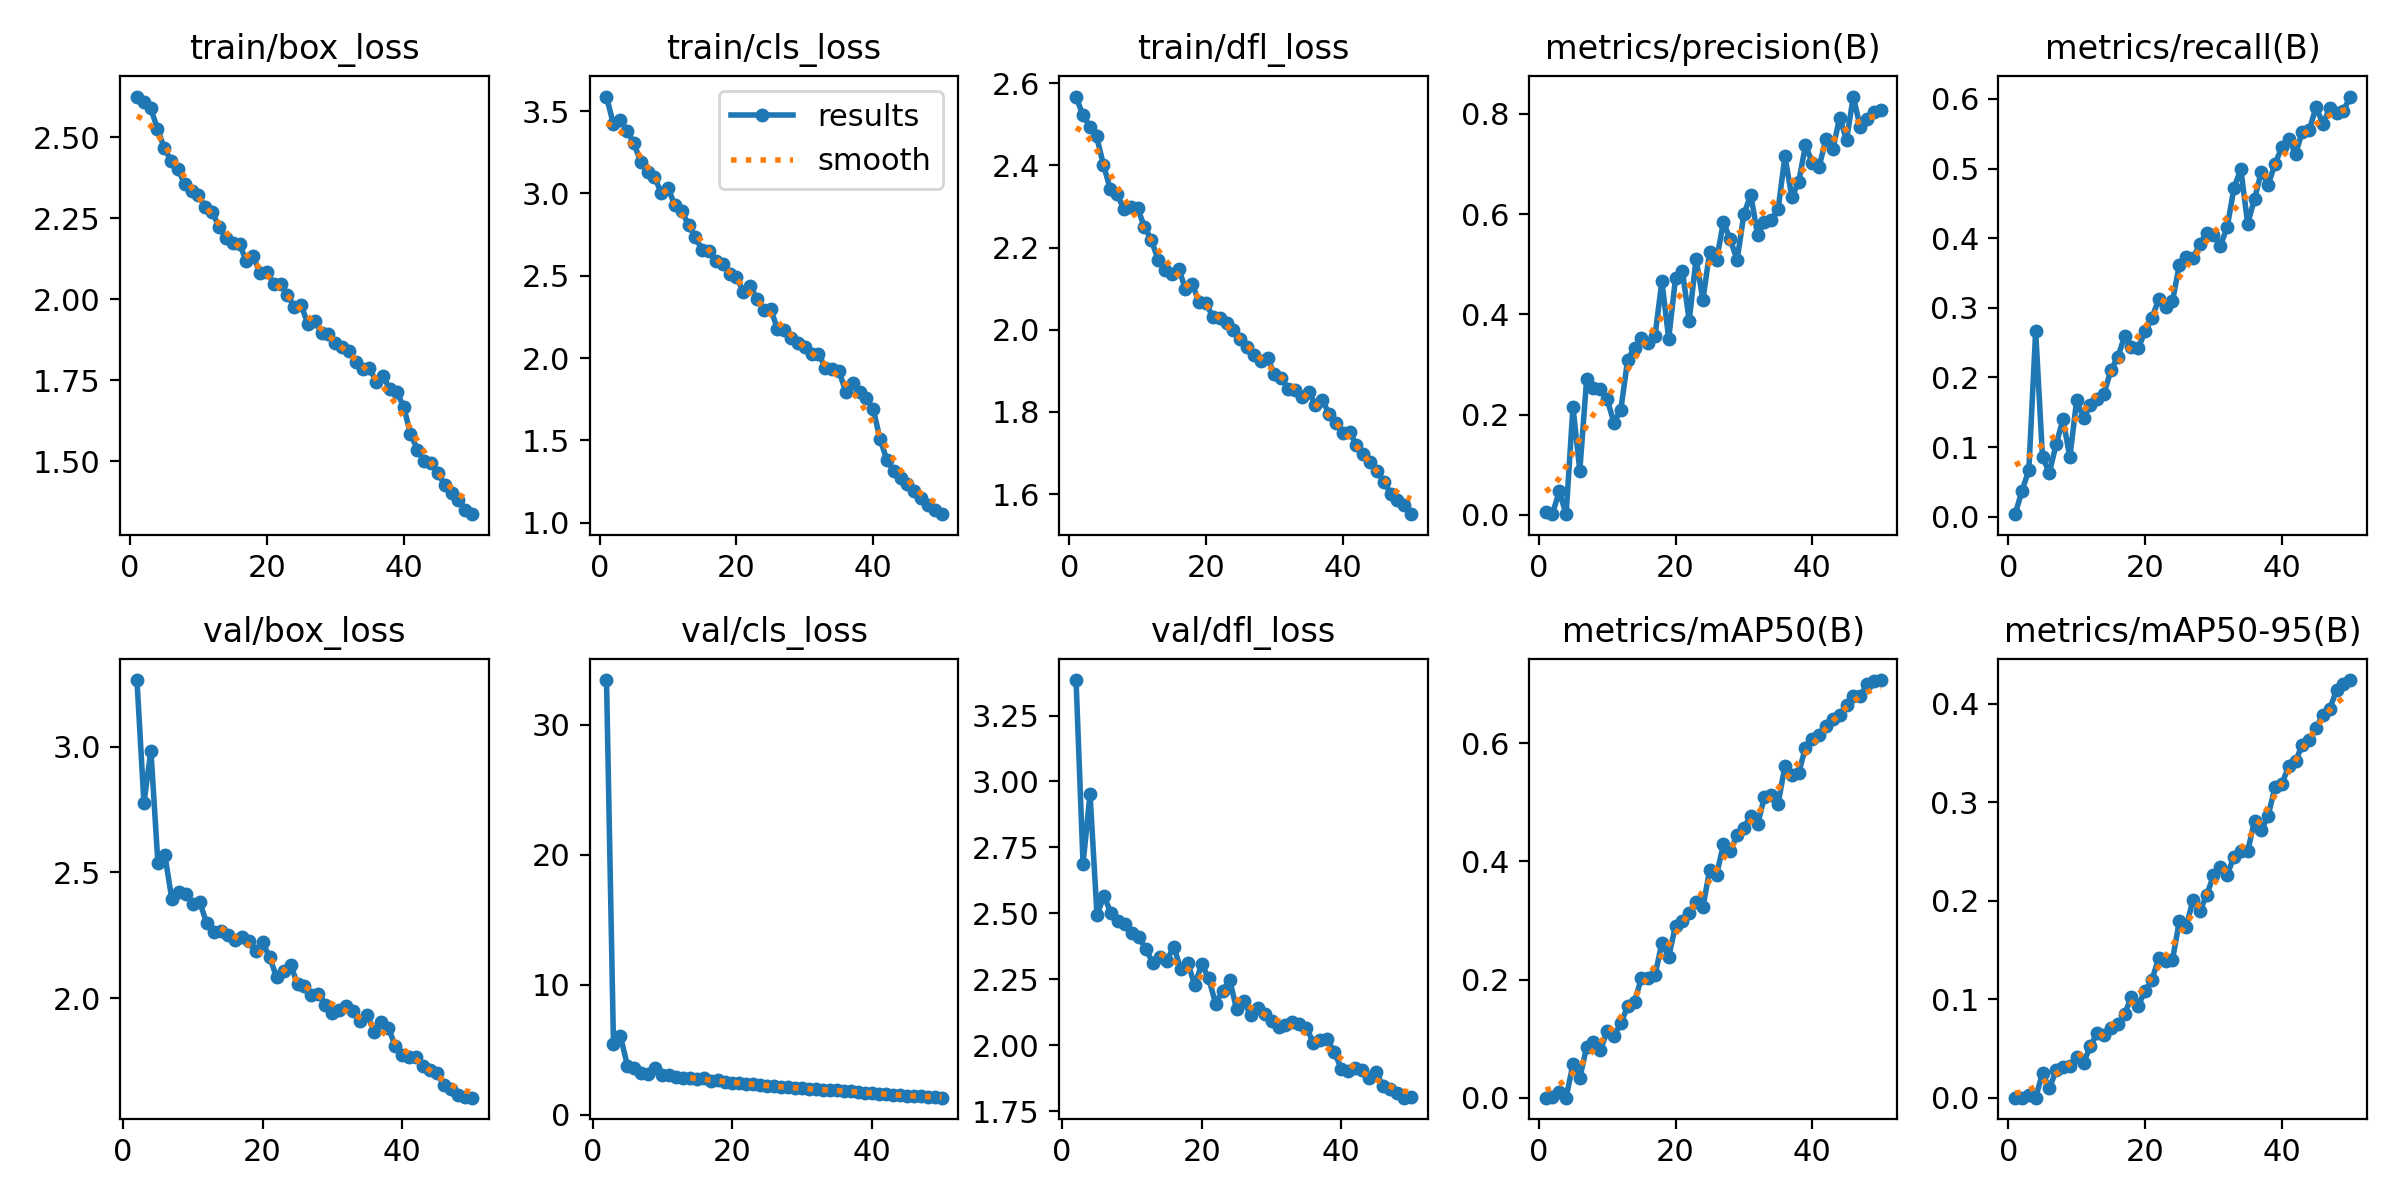

✅ Training metrics plot loaded

📊 FINAL METRICS SUMMARY:
Best mAP50 (Validation): 0.71%
Best mAP50 (Test): 0.68%
Precision: 0.76%
Recall: 0.60%


In [11]:
# ============================================================================
# BLOCK 8: VISUALIZE TRAINING PROGRESS
# ============================================================================

print("="*70)
print("VISUALIZING TRAINING METRICS")
print("="*70)

# CORRECTED PATH - includes runs/detect/
results_dir = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean'

if os.path.exists(f"{results_dir}/results.png"):
    from IPython.display import Image as IPImage
    display(IPImage(f"{results_dir}/results.png"))
    print("✅ Training metrics plot loaded")
else:
    print("⚠️ results.png not found yet")

print("\n📊 FINAL METRICS SUMMARY:")
print("="*50)
print(f"Best mAP50 (Validation): {val_results.box.map50:.2f}%")
print(f"Best mAP50 (Test): {test_results.box.map50:.2f}%")
print(f"Precision: {test_results.box.mp:.2f}%")
print(f"Recall: {test_results.box.mr:.2f}%")
print("="*50)

# **BLOCK 9: SAVE BEST MODEL FOR DOWNLOAD**

In [12]:
# ============================================================================
# BLOCK 9: SAVE BEST MODEL FOR DOWNLOAD
# ============================================================================

print('='*70)
print('SAVING BEST MODEL')
print('='*70)

import shutil, json

# CORRECTED PATHS - includes runs/detect/
best_model_source = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt'
last_model_source = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/last.pt'
best_pt_dest = '/kaggle/working/yolo_best_model_filtered.pt'
last_pt_dest = '/kaggle/working/yolo_last_model_filtered.pt'

if os.path.exists(best_model_source):
    shutil.copy(best_model_source, best_pt_dest)
    print(f'✅ Best model saved: {best_pt_dest}')
    print(f'   Size: {os.path.getsize(best_pt_dest) / (1024*1024):.1f} MB')
else:
    print(f'❌ Best model not found at: {best_model_source}')

if os.path.exists(last_model_source):
    shutil.copy(last_model_source, last_pt_dest)
    print(f'✅ Last model saved: {last_pt_dest}')

from IPython.display import FileLink, display
print('\n📥 Download links:')
for fpath in [best_pt_dest, last_pt_dest]:
    if os.path.exists(fpath):
        display(FileLink(fpath))

print('='*70)

SAVING BEST MODEL
✅ Best model saved: /kaggle/working/yolo_best_model_filtered.pt
   Size: 49.6 MB
✅ Last model saved: /kaggle/working/yolo_last_model_filtered.pt

📥 Download links:


/kaggle/working/yolo_best_model_filtered.pt

/kaggle/working/yolo_last_model_filtered.pt

# **BLOCK 10: EXPORT TO H5 FORMAT**

In [14]:
# ============================================================================
# BLOCK 10: EXPORT TO DEPLOYMENT FORMATS
# ============================================================================

print('='*70)
print('EXPORTING MODEL TO DEPLOYMENT FORMATS')
print('='*70)

from ultralytics import YOLO
import os

best_model_source = '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt'

if not os.path.exists(best_model_source):
    print(f"❌ Model not found: {best_model_source}")
else:
    print(f"✅ Loading model from: {best_model_source}")
    model = YOLO(best_model_source)
    
    # Option 1: Export to ONNX (best for deployment)
    print("\n📤 Exporting to ONNX format...")
    onnx_path = model.export(format='onnx')
    print(f"✅ ONNX model saved: {onnx_path}")
    
    # Option 2: Export to TorchScript (PyTorch deployment)
    print("\n📤 Exporting to TorchScript format...")
    torchscript_path = model.export(format='torchscript')
    print(f"✅ TorchScript model saved: {torchscript_path}")
    
    # Option 3: Export to SavedModel (TensorFlow)
    print("\n📤 Exporting to SavedModel format...")
    saved_model_path = model.export(format='saved_model')
    print(f"✅ SavedModel saved: {saved_model_path}")
    
    print("\n" + "="*70)
    print("📥 DOWNLOAD LINKS:")
    print("="*70)
    
    from IPython.display import FileLink, display
    
    # Find all exported files
    export_dir = os.path.dirname(best_model_source)
    for file in os.listdir(export_dir):
        if file.endswith(('.onnx', '.pt', '.zip')):
            file_path = os.path.join(export_dir, file)
            print(f"\n📁 {file}")
            display(FileLink(file_path))
    
    # Also check parent directory for saved_model folder
    parent_dir = os.path.dirname(export_dir)
    for item in os.listdir(parent_dir):
        if 'saved_model' in item or 'onnx' in item:
            item_path = os.path.join(parent_dir, item)
            if os.path.isdir(item_path):
                print(f"\n📁 {item}/ (folder)")
                display(FileLink(item_path))

print('='*70)

EXPORTING MODEL TO DEPLOYMENT FORMATS
✅ Loading model from: /kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt

📤 Exporting to ONNX format...
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 252ms
Prepared 2 packages in 3.20s
Installed 2 packages in 19ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: Auto

I0000 00:00:1778361902.030169      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10331 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778361902.035461      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778361907.757707      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 5, 8400), dtype=tf.float32, name=None)
Captures:
  138959480200208: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138959480199056: TensorSpec(shape=(3, 3, 3, 48), dtype=tf.float32, name=None)
  138959480199440: TensorSpec(shape=(48,), dtype=tf.float32, name=None)
  138959480204624: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138959480205008: TensorSpec(shape=(3, 3, 48, 96), dtype=tf.float32, name=None)
  138959480203088: TensorSpec(shape=(96,), dtype=tf.float32, name=None)
  138959480205200: TensorSpec(shape=(1, 1, 96, 96), dtype=tf.float32, name=None)
  138959480205392: TensorSpec(shape=(96,), dtype=tf.float32, name=None)
  138959480193680: TensorSpe

I0000 00:00:1778361915.372401      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1778361915.372623      57 single_machine.cc:374] Starting new session
I0000 00:00:1778361915.386161      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10331 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778361915.387785      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1778361919.676467      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778361919.676505      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778361923.260450      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1778361923.260

TensorFlow SavedModel: export success ✅ 37.9s, saved as '/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model' (247.1 MB)

Export complete (39.6s)
Results saved to /kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model imgsz=640 data=/kaggle/working/filtered_data.yaml  
Visualize:       https://netron.app
✅ SavedModel saved: /kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best_saved_model

📥 DOWNLOAD LINKS:

📁 epoch45.pt


...

/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/epoch5.pt


📁 best.onnx


/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/best.onnx


📁 epoch35.pt


/kaggle/working/runs/detect/shoulder_arm_yolo_filtered/run_50epochs_clean/weights/epoch35.pt